In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform

# IBE

In [ ]:
def extract_xy(gen_df, dist_df, env_df):
    pops = gen_df.index.intersection(dist_df.index).intersection(env_df.index)

    M1 = gen_df.loc[pops, pops].values
    M2 = dist_df.loc[pops, pops].values
    M3 = env_df.loc[pops, pops].values

    x = squareform(M2, checks=False)
    y = squareform(M1, checks=False)
    z = squareform(M3, checks=False)

    return x, y, z


def plot_ibe_panel(ax, gen_df, dist_df, env_df, colors,
                   ylabel=r"$F_{ST}$/(1-$F_{ST}$)",
                   show_xlabel=True,
                   show_ylabel=True,
                   title=""):

    x_data, y_data, z_data = extract_xy(gen_df, dist_df, env_df)

    mask_same = z_data == 0
    ax.scatter(
        x_data[mask_same],
        y_data[mask_same],
        s=7,
        alpha=0.9,
        color=colors.get(0),
        label="Same"
    )

    mask_diff = z_data == 1
    ax.scatter(
        x_data[mask_diff],
        y_data[mask_diff],
        s=7,
        alpha=0.9,
        color=colors.get(1),
        label="Different"
    )

    sns.regplot(
        x=x_data,
        y=y_data,
        scatter=False,
        ax=ax,
        line_kws={"lw": 1.1},
        color=colors.get(2)
    )

    # ax.set_ylim(-0.05, 0.4)
    if show_xlabel:
        ax.set_xlabel("Geographic distance (km)", fontsize=12)
    else:
        ax.set_xlabel("")

    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=12)
    else:
        ax.set_ylabel("")

    if title:
        ax.set_title(title, fontsize=12)


def plot_ibe_grid(base_dir="/mantel_test/dist_matrices",
                  species=("GSL", "SSL"),
                  chromosomes=("MT", "X", "AUT", "Y"),
                  colors=None,
                  figsize=(8, 10),
                  dpi=120):

    if colors is None:
        colors = {
            "GSL": {0: "#11819f", 1: "#00c6c2", 2: "#7c80cd"},
            "SSL": {0: "#770076", 1: "#e459b9", 2: "#f5f455"}
        }

    fig, axes = plt.subplots(
        nrows=len(chromosomes),
        ncols=len(species),
        figsize=figsize,
        dpi=dpi,
        sharex=False,
        sharey=False
    )

    for col, sp in enumerate(species):
        for row, chrom in enumerate(chromosomes):

            if chrom in ["X", "AUT"]:
                gen_path = f"{base_dir}/gen_dist_{sp}_{chrom}.txt"
            else:
                gen_path = f"{base_dir}/gen_dist_phist_{sp}_{chrom}.txt"

            dist_path = f"{base_dir}/geo_dist_{sp}.txt"
            env_path = f"{base_dir}/env_dist_{sp}.txt"

            gen_df = pd.read_csv(gen_path, sep=" ", index_col=0, header=0)
            dist_df = pd.read_csv(dist_path, sep=" ", index_col=0, header=0)
            env_df = pd.read_csv(env_path, sep=" ", index_col=0, header=0)

            ylabel = (
                r"$\Phi_{ST}$"
                if chrom in ["MT", "Y"]
                else r"$F_{ST}$/(1-$F_{ST}$)"
            )

            ax = axes[row, col]

            plot_ibe_panel(
                ax=ax,
                gen_df=gen_df,
                dist_df=dist_df,
                env_df=env_df,
                colors=colors[sp],
                ylabel=ylabel,
                show_xlabel=(row == len(chromosomes) - 1),
                show_ylabel=(col == 0),
                title=sp if row == 0 else ""
            )

            # row label: MT, X, AUT, Y
            if col == 0:
                ax.text(
                    -0.28, 0.5, chrom,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold"
                )

            if row == 0 and col == len(species)-1:
                ax.legend(
                    title="Environment",
                    frameon=True,
                    loc="upper right",
                    fontsize=9
                )
            elif row == 0 and col == 0:
                ax.legend(
                    title="Environment",
                    frameon=True,
                    loc="upper left",
                    fontsize=9
                )
            else:
                leg = ax.get_legend()
                if leg is not None:
                    leg.remove()

    plt.tight_layout()
    plt.show()

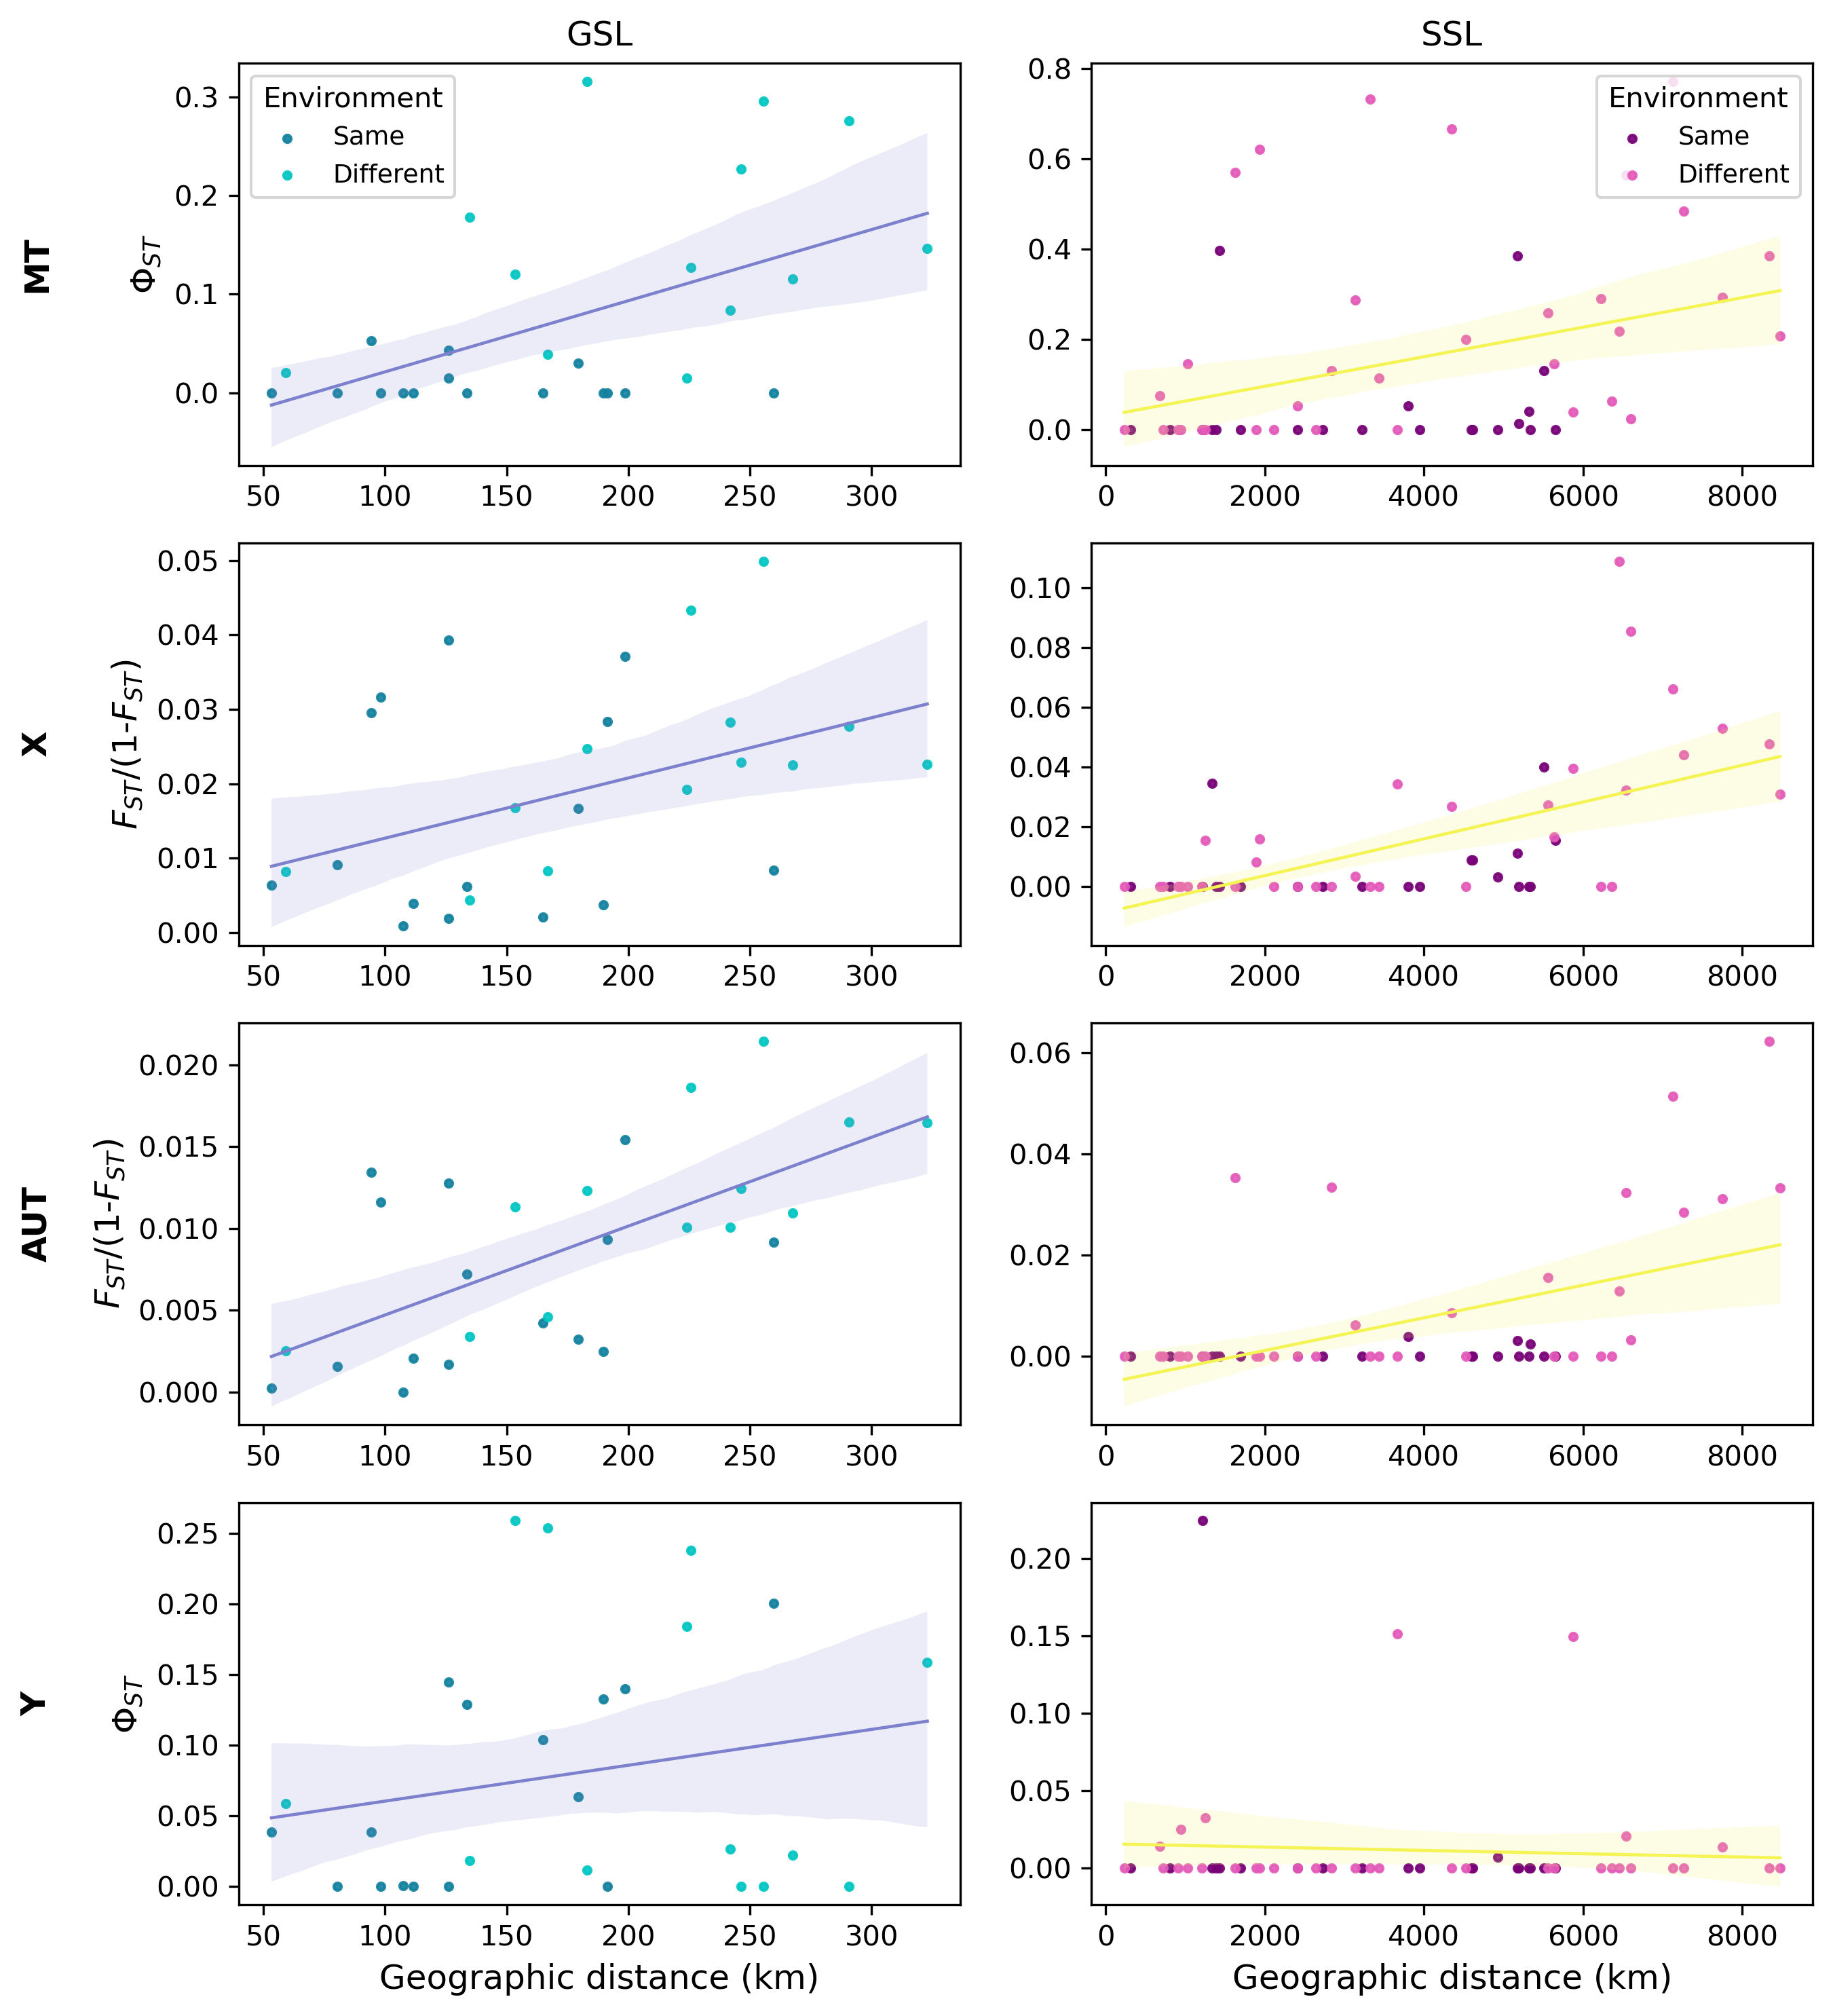

In [93]:
plot_ibe_grid(figsize=(9, 10), dpi=300)